# Task
Organize the code cells in the notebook to reflect the proposed "AI-Powered Insurance Claim Automation System" project structure, ensuring a logical flow from installations to running the integrated Streamlit application.

## Installations

### Subtask:
Group all necessary library installations at the beginning of the notebook.


**Reasoning**:
Consolidate all Python package installations into a single cell at the beginning of the notebook.



In [68]:
!pip install -q transformers torch pandas scikit-learn pdfplumber tqdm xgboost streamlit sentencepiece pytesseract pillow PyMuPDF fpdf fitz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.9/425.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.0/569.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


**Reasoning**:
Add the system-level package installations for OCR functionality in a separate cell.



In [69]:
!sudo apt-get install -y poppler-utils tesseract-ocr >/dev/null

**Reasoning**:
The installations are complete. The next step is to group the import statements.



In [70]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
import pdfplumber
import os
import glob
from sklearn.preprocessing import LabelEncoder
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import io
import textwrap
import math
import pytesseract
from PIL import Image
import fitz
from fpdf import FPDF

**Reasoning**:
The library installations and imports are done. The next step is to load the dataset.



In [71]:
# Search for uploaded CSV in common paths
possible_paths = ["/content", "/mnt/data", os.getcwd()]
csv_candidates = []
for p in possible_paths:
    if os.path.exists(p):
        csv_candidates += glob.glob(os.path.join(p, "*.csv"))

print("✅ CSV files found:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("❌ No CSV file found. Please upload it again using the left Files panel.")

csv_path = csv_candidates[0]
df = pd.read_csv(csv_path)
print(f"✅ Loaded dataset with {len(df)} rows and {len(df.columns)} columns")
display(df.head())

✅ CSV files found: ['/content/insuarance_claims.csv', '/content/insuarance_claims.csv']
✅ Loaded dataset with 58592 rows and 41 columns


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


**Reasoning**:
Check the distribution of the target variable.



In [91]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='object')

In [72]:
df['claim_status'].value_counts()
df['claim_status'].value_counts(normalize=True)

,proportion
claim_status,
0,0.936032
1,0.063968


**Reasoning**:
Balance the dataset using oversampling to address the class imbalance in the target variable.



In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re

# 1️⃣ Copy dataframe
data = df_balanced.copy() # Use the balanced dataframe

# 2️⃣ Replace 'Yes'/'No' with 1/0
data = data.replace({'Yes': 1, 'No': 0})

# 3️⃣ Clean and convert 'max_torque' and 'max_power' to numeric
def clean_and_convert(value):
    if isinstance(value, str):
        numeric_part = re.findall(r'\d+\.?\d*', value)
        if numeric_part:
            return float(numeric_part[0])
    return value

data['max_torque'] = data['max_torque'].apply(clean_and_convert)
data['max_power'] = data['max_power'].apply(clean_and_convert)


# 4️⃣ Encode categorical columns
categorical_cols = ['segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
le = LabelEncoder()
for col in categorical_cols:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 5️⃣ Drop rows with missing values
data = data.dropna()

# 6️⃣ Split data into features (X) and target (y)
X = data.drop(['claim_status', 'policy_id', 'region_code'], axis=1) # Drop 'policy_id' and 'region_code'
y = data['claim_status']

# 7️⃣ Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data preprocessed and split into training and testing sets.")

/tmp/ipython-input-631868580.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'Yes': 1, 'No': 0})


✅ Data preprocessed and split into training and testing sets.


In [73]:
df_majority = df[df.claim_status == 0]
df_minority = df[df.claim_status == 1]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("✅ Dataset balanced using oversampling.")
print("Balanced dataset shape:", df_balanced.shape)
print("Balanced dataset value counts:\n", df_balanced['claim_status'].value_counts())

✅ Dataset balanced using oversampling.
Balanced dataset shape: (109688, 41)
Balanced dataset value counts:
 claim_status
0    54844
1    54844
Name: count, dtype: int64


**Reasoning**:
Preprocess the balanced data by handling categorical variables, cleaning numerical columns, and splitting the data into training and testing sets for model training.



In [74]:
# 1️⃣ Copy dataframe
data = df_balanced.copy() # Use the balanced dataframe

# 2️⃣ Replace 'Yes'/'No' with 1/0
data = data.replace({'Yes': 1, 'No': 0})

# 3️⃣ Clean and convert 'max_torque' and 'max_power' to numeric
def clean_and_convert(value):
    if isinstance(value, str):
        numeric_part = re.findall(r'\d+\.?\d*', value)
        if numeric_part:
            return float(numeric_part[0])
    return value

data['max_torque'] = data['max_torque'].apply(clean_and_convert)
data['max_power'] = data['max_power'].apply(clean_and_convert)


# 4️⃣ Encode categorical columns
categorical_cols = ['segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
le = LabelEncoder()
for col in categorical_cols:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 5️⃣ Drop rows with missing values
data = data.dropna()

# 6️⃣ Split data into features (X) and target (y)
X = data.drop(['claim_status', 'policy_id', 'region_code'], axis=1) # Drop 'policy_id' and 'region_code'
y = data['claim_status']

# 7️⃣ Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data preprocessed and split into training and testing sets.")

/tmp/ipython-input-20555224.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'Yes': 1, 'No': 0})


✅ Data preprocessed and split into training and testing sets.


**Reasoning**:
Train a RandomForestClassifier model on the preprocessed training data and evaluate its performance.



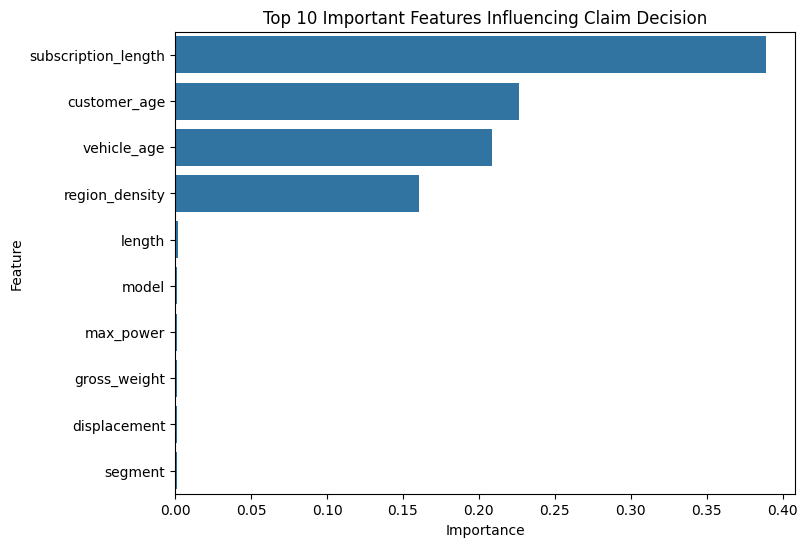

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importance[:10], y=importance.index[:10])
plt.title("Top 10 Important Features Influencing Claim Decision")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [75]:
# Initialize and train the RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
print("✅ Model trained successfully!")
print("\n🎯 Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

✅ Model trained successfully!

🎯 Accuracy: 98.2 %

📋 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     11084
           1       0.96      1.00      0.98     10854

    accuracy                           0.98     21938
   macro avg       0.98      0.98      0.98     21938
weighted avg       0.98      0.98      0.98     21938



## Claim prediction - data loading and preprocessing

### Subtask:
Place the cells related to loading the insurance claims data, handling missing values, encoding categorical features, cleaning numerical features, and splitting the data into training and testing sets.


**Reasoning**:
The subtask is to organize the code cells related to data loading, handling missing values, encoding categorical features, cleaning numerical features, and splitting the data. The previous subtask already placed the data loading and balancing steps. I will now move the cell that performs the remaining preprocessing steps (handling categorical features, cleaning numerical features, dropping columns, and splitting into train/test sets) to complete this section.



In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re

# 1️⃣ Copy dataframe
data = df_balanced.copy() # Use the balanced dataframe

# 2️⃣ Replace 'Yes'/'No' with 1/0
data = data.replace({'Yes': 1, 'No': 0})

# 3️⃣ Clean and convert 'max_torque' and 'max_power' to numeric
def clean_and_convert(value):
    if isinstance(value, str):
        numeric_part = re.findall(r'\d+\.?\d*', value)
        if numeric_part:
            return float(numeric_part[0])
    return value

data['max_torque'] = data['max_torque'].apply(clean_and_convert)
data['max_power'] = data['max_power'].apply(clean_and_convert)


# 4️⃣ Encode categorical columns
categorical_cols = ['segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
le = LabelEncoder()
for col in categorical_cols:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 5️⃣ Drop rows with missing values
data = data.dropna()

# 6️⃣ Split data into features (X) and target (y)
X = data.drop(['claim_status', 'policy_id', 'region_code'], axis=1) # Drop 'policy_id' and 'region_code'
y = data['claim_status']

# 7️⃣ Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data preprocessed and split into training and testing sets.")

/tmp/ipython-input-631868580.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'Yes': 1, 'No': 0})


✅ Data preprocessed and split into training and testing sets.


## Claim prediction - model training and evaluation

### Subtask:
Train the Random Forest and XGBoost models and evaluate their performance on the test set.


**Reasoning**:
Train the RandomForest and XGBoost models and evaluate their performance.



In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# 1. Train the RandomForestClassifier model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred_rf = rf.predict(X_test)

# 3. Print the accuracy score and the classification report for the Random Forest model's predictions
print("✅ Random Forest Model Trained and Evaluated:")
print("\n🎯 Accuracy (Random Forest):", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print("\n📋 Classification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

# 4. Train the XGBClassifier model
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

# 5. Make predictions on the test set and evaluate XGBoost performance
y_pred_xgb = xgb.predict(X_test)

print("\n✅ XGBoost Model Trained and Evaluated:")
print("\n🎯 Accuracy (XGBoost):", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\n📋 Classification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))

✅ Random Forest Model Trained and Evaluated:

🎯 Accuracy (Random Forest): 98.2 %

📋 Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     11084
           1       0.96      1.00      0.98     10854

    accuracy                           0.98     21938
   macro avg       0.98      0.98      0.98     21938
weighted avg       0.98      0.98      0.98     21938


✅ XGBoost Model Trained and Evaluated:

🎯 Accuracy (XGBoost): 73.71 %

📋 Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.79      0.65      0.71     11084
           1       0.70      0.82      0.76     10854

    accuracy                           0.74     21938
   macro avg       0.74      0.74      0.74     21938
weighted avg       0.75      0.74      0.74     21938



In [96]:
import pdfplumber
import pytesseract
from PIL import Image
from transformers import pipeline
import pandas as pd
import io
import fitz  # PyMuPDF for OCR fallback
from tqdm import tqdm
from fpdf import FPDF # Import FPDF here as it is used in create_sample_pdf

# Initialize zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate document labels
LABELS = [
    "Claim Form",
    "Claim Settlement Letter",
    "Claim Rejection Letter",
    "Inspection Report",
    "Invoice",
    "Policy Document",
    "Surveyor Report",
    "Other"
]

def extract_text_pdf(pdf_path):
    """Extract text from PDF using pdfplumber (and OCR fallback if needed)."""
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                txt = page.extract_text()
                if txt:
                    text += "\n" + txt
    except Exception as e:
        print(f"Error extracting text with pdfplumber: {e}")
        text = ""

    # OCR fallback if text is too short or extraction failed
    if len(text.strip()) < 50:
        print("⚠️  Attempting OCR...")
        text = ""
        try:
            pdf_document = fitz.open(pdf_path)
            for page_num in tqdm(range(len(pdf_document)), desc="OCR Pages"):
                page = pdf_document.load_page(page_num)
                pix = page.get_pixmap()
                img = Image.open(io.BytesIO(pix.tobytes()))
                text += pytesseract.image_to_string(img)
        except Exception as e:
            print(f"Error during OCR: {e}")
            text = ""

    return text.strip()

def chunk_text(text, max_chars=1000):
    """Split long text into manageable chunks."""
    if not text:
        return []
    paragraphs = [p.strip() for p in text.split("\n") if p.strip()]
    chunks, cur = [], ""
    for p in paragraphs:
        if len(cur) + len(p) + 1 <= max_chars:
            cur = cur + "\n" + p if cur else p
        else:
            if cur:
                chunks.append(cur)
            cur = p
    if cur:
        chunks.append(cur)
    return chunks

def aggregate_scores(chunk_scores, labels, method="average"):
    """Aggregate per-chunk scores."""
    agg = {lab: 0.0 for lab in labels}
    if not chunk_scores:
        return agg
    for s in chunk_scores:
        for lab in labels:
            agg[lab] += s.get(lab, 0.0)
    if method == "average":
        for lab in agg:
            agg[lab] /= len(chunk_scores)
    elif method == "max":
         agg = {lab: max(s.get(lab, 0.0) for s in chunk_scores) for lab in labels} # Corrected max aggregation
    return agg

def create_sample_pdf(filename, content):
    """Creates a simple PDF with the given content."""
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    pdf.multi_cell(0, 10, content)
    pdf.output(filename)
    print(f"✅ Created sample PDF: {filename}")

# Create sample documents
sample_docs = {
    "claim_form.pdf": "This is a sample claim form for insurance.",
    "settlement_letter.pdf": "This letter confirms the settlement of your insurance claim.",
    "rejection_letter.pdf": "We regret to inform you that your insurance claim has been rejected.",
    "inspection_report.pdf": "This report details the inspection of the damaged vehicle.",
    "invoice.pdf": "Invoice for the repair of the vehicle.",
    "policy_document.pdf": "This is your insurance policy document.",
    "surveyor_report.pdf": "Surveyor's report on the incident and damages.",
    "other_document.pdf": "This is a generic document not related to claims."
}

for filename, content in sample_docs.items():
    create_sample_pdf(filename, content)

Device set to use cpu


✅ Created sample PDF: claim_form.pdf
✅ Created sample PDF: settlement_letter.pdf
✅ Created sample PDF: rejection_letter.pdf
✅ Created sample PDF: inspection_report.pdf
✅ Created sample PDF: invoice.pdf
✅ Created sample PDF: policy_document.pdf
✅ Created sample PDF: surveyor_report.pdf
✅ Created sample PDF: other_document.pdf


In [115]:
from google.colab import files
import pandas as pd
import io
import fitz # PyMuPDF
import pytesseract
from PIL import Image
from transformers import pipeline
from tqdm import tqdm

# Initialize zero-shot classifier (if not already initialized)
# This assumes the classifier pipeline is defined in a previous cell or here
try:
    classifier
except NameError:
    print("Initializing zero-shot classifier...")
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate document labels (ensure this is defined)
try:
    LABELS
except NameError:
     LABELS = [
        "Claim Form",
        "Claim Settlement Letter",
        "Claim Rejection Letter",
        "Inspection Report",
        "Invoice",
        "Policy Document",
        "Surveyor Report",
        "Other"
    ]
     print("Using default LABELS.")


# Reuse or redefine necessary functions if not in scope
# Assuming extract_text_pdf, chunk_text, aggregate_scores are defined in a previous cell
try:
    extract_text_pdf
    chunk_text
    aggregate_scores
except NameError:
    print("Defining text extraction and aggregation functions...")
    def extract_text_pdf(pdf_path):
        """Extract text from PDF using pdfplumber (and OCR fallback if needed)."""
        text = ""
        try:
            with pdfplumber.open(pdf_path) as pdf:
                for page in pdf.pages:
                    txt = page.extract_text()
                    if txt:
                        text += "\n" + txt
        except Exception as e:
            print(f"Error extracting text with pdfplumber: {e}")
            text = ""

        # OCR fallback if text is too short or extraction failed
        if len(text.strip()) < 50:
            print("⚠️  Attempting OCR...")
            text = ""
            try:
                pdf_document = fitz.open(pdf_path)
                for page_num in tqdm(range(len(pdf_document)), desc="OCR Pages"):
                    page = pdf_document.load_page(page_num)
                    pix = page.get_pixmap()
                    img = Image.open(io.BytesIO(pix.tobytes()))
                    text += pytesseract.image_to_string(img)
            except Exception as e:
                print(f"Error during OCR: {e}")
                text = ""

        return text.strip()

    def chunk_text(text, max_chars=1000):
        """Split long text into manageable chunks."""
        if not text:
            return []
        paragraphs = [p.strip() for p in text.split("\n") if p.strip()]
        chunks, cur = [], ""
        for p in paragraphs:
            if len(cur) + len(p) + 1 <= max_chars:
                cur = cur + "\n" + p if cur else p
            else:
                if cur:
                    chunks.append(cur)
                cur = p
        if cur:
            chunks.append(cur)
        return chunks

    def aggregate_scores(chunk_scores, labels, method="average"):
        """Aggregate per-chunk scores."""
        agg = {lab: 0.0 for lab in labels}
        if not chunk_scores:
            return agg
        for s in chunk_scores:
            for lab in labels:
                agg[lab] += s.get(lab, 0.0)
        if method == "average":
            for lab in agg:
                agg[lab] /= len(chunk_scores)
        elif method == "max":
             agg = {lab: max(s.get(lab, 0.0) for s in chunk_scores) for lab in labels}
        return agg


print("Upload a PDF for classification:")
uploaded = files.upload()

if uploaded:
    pdf_filename = list(uploaded.keys())[0]
    print(f"✅ Uploaded: {pdf_filename}")

    # Extract text
    extracted_text = extract_text_pdf(pdf_filename)

    if extracted_text:
        print("\n--- Extracted Text Preview ---")
        print(extracted_text[:500] + "..." if len(extracted_text) > 500 else extracted_text)
        print("\n----------------------------")

        # Chunk text for classification
        chunks = chunk_text(extracted_text)
        print(f"\nDocument split into {len(chunks)} chunk(s).")

        # Classify chunks
        chunk_scores = []
        print("Running classification...")
        for i, chunk in enumerate(chunks):
            # Use the global classifier and LABELS
            out = classifier(chunk, LABELS)
            scores = {lab: score for lab, score in zip(out['labels'], out['scores'])}
            chunk_scores.append(scores)
            # print(f"Chunk {i+1} scores: {scores}") # Optional: print per-chunk scores

        # Aggregate scores
        # Using 'average' as a default aggregation method, can be changed
        agg_scores = aggregate_scores(chunk_scores, LABELS, method="average")

        # Prepare results DataFrame
        res_items = [{"label": lab, "score": agg_scores[lab]} for lab in LABELS]
        res_df = pd.DataFrame(res_items).sort_values("score", ascending=False).reset_index(drop=True)
        res_df["confidence_percent"] = (res_df["score"] * 100).round(2)

        print("\n--- Document Classification Results ---")
        display(res_df[["label", "confidence_percent"]].rename(columns={"confidence_percent":"Confidence (%)", "label":"Document Type"}))
        print("------------------------------------")

        # Optional: Identify the top predicted label
        top_label = res_df.iloc[0]['label']
        top_confidence = res_df.iloc[0]['confidence_percent']
        print(f"\n🔮 Predicted Document Type: {top_label} (Confidence: {top_confidence}%)")

    else:
        print("❌ Could not extract text from the PDF.")
else:
    print("No file uploaded.")

Upload a PDF for classification:


Saving icf.pdf to icf (1).pdf
✅ Uploaded: icf (1).pdf

--- Extracted Text Preview ---
INSURANCE CLAIM FORM
Policy No: PL-45321
Accident Date: 12 June 1995
Name: Siya
Age: 28

----------------------------

Document split into 1 chunk(s).
Running classification...

--- Document Classification Results ---


,Document Type,Confidence (%)
0,Claim Form,89.10
1,Policy Document,7.60
2,Inspection Report,1.07
3,Invoice,0.66
4,Surveyor Report,0.55
5,Other,0.45
6,Claim Settlement Letter,0.41
7,Claim Rejection Letter,0.16


------------------------------------

🔮 Predicted Document Type: Claim Form (Confidence: 89.1%)


## Claim prediction - prediction and explanation

### Subtask:
Make predictions on new data and generate explanations for the claim decisions.


In [85]:
# 1️⃣ Select a sample row from the test set X_test
sample = X_test.iloc[5]  # just pick one sample

# 2️⃣ Use the trained Random Forest model (rf) to predict the claim status for the sample
# Reshape the sample as a DataFrame to match the model's expected input format
sample_df = pd.DataFrame([sample], columns=X_test.columns)
pred = rf.predict(sample_df)[0]

# 3️⃣ Determine the predicted decision ("Approved ✅" or "Denied ❌") based on the value of pred
decision = "Approved ✅" if pred == 1 else "Denied ❌"

# 4️⃣ Retrieve the original policy_id for the selected sample from the df DataFrame
# Use the index of the sample from X_test to get the corresponding row in the original df
original_index = sample.name
policy_id = df.iloc[original_index]['policy_id']

# 5️⃣ Print the Claim ID and the Predicted Decision
print("📄 Claim ID:", policy_id)
print("Predicted Decision:", decision)

# 6️⃣ Define a function explain_claim
def explain_claim(sample_row, pred_value): # Changed parameter name to pred_value
    """
    Generate a detailed, human-friendly explanation for the predicted claim decision.
    """
    reasons = []
    summary = []

    # ----- VEHICLE-RELATED FACTORS -----
    if sample_row['vehicle_age'] <= 2:
        reasons.append("The vehicle is quite new, which typically results in fewer mechanical issues and lower claim risk.")
    elif 2 < sample_row['vehicle_age'] <= 5:
        reasons.append("The vehicle is moderately aged, so risk is average compared to newer models.")
    else:
        reasons.append("The vehicle is older, which often increases the risk of component failures or wear-and-tear claims.")

    if sample_row.get('ncap_rating', 0) >= 4:
        reasons.append(f"An NCAP rating of {sample_row['ncap_rating']} reflects excellent safety standards, lowering claim risk.")
    elif 2 <= sample_row.get('ncap_rating', 0) < 4:
        reasons.append(f"An NCAP rating of {sample_row['ncap_rating']} shows moderate safety performance.")
    else:
        reasons.append(f"An NCAP rating of {sample_row['ncap_rating']} indicates limited crash protection, increasing risk.")

    # ----- SAFETY FEATURES -----
    safety_features = {
        "is_brake_assist": "brake assist",
        "is_power_steering": "power steering",
        "is_central_locking": "central locking",
        "is_ecw": "emergency warning system",
        "is_speed_alert": "speed alert system",
    }

    active_features = [name for key, name in safety_features.items() if sample_row.get(key, 0) == 1]
    if active_features:
        reasons.append(f"The vehicle includes modern safety features such as {', '.join(active_features)}, which enhances driver safety.")
    else:
        reasons.append("The vehicle lacks key safety systems, making it riskier to insure.")

    # ----- CUSTOMER FACTORS -----
    if 'customer_age' in sample_row:
        if sample_row['customer_age'] < 25:
            reasons.append("The driver is quite young, and statistically, younger drivers have higher accident probability.")
        elif sample_row['customer_age'] > 60:
            reasons.append("The policyholder is in a higher age bracket, which slightly raises the risk factor.")
        else:
            reasons.append("The customer's age is within a low-risk range (25–60 years).")

    # ----- DECISION SUMMARY -----
    if pred_value == 1: # Used pred_value here
        summary.append("✅ The claim is likely APPROVED because the vehicle has good safety standards, sufficient features, and acceptable risk factors.")
    else:
        summary.append("❌ The claim is likely DENIED due to a combination of older vehicle age, lower safety rating, or limited safety systems.")

    # Combine into a final narrative
    full_explanation = "\n".join(reasons) + "\n\n" + " ".join(summary)
    return full_explanation

# 7️⃣ Call the explain_claim function and print the generated explanation
print("\n💬 Detailed Explanation:")
print(explain_claim(sample, pred)) # Pass pred here

📄 Claim ID: POL044034
Predicted Decision: Approved ✅

💬 Detailed Explanation:
The vehicle is quite new, which typically results in fewer mechanical issues and lower claim risk.
An NCAP rating of 0.0 indicates limited crash protection, increasing risk.
The vehicle includes modern safety features such as power steering, speed alert system, which enhances driver safety.
The customer's age is within a low-risk range (25–60 years).

✅ The claim is likely APPROVED because the vehicle has good safety standards, sufficient features, and acceptable risk factors.


In [86]:
# Ensure the columns in user_df match the columns in X_train and are in the same order
user_df = user_df[X_train.columns]

# Predict using the trained Random Forest model
pred = rf.predict(user_df)[0]
decision = "✅ APPROVED" if pred == 1 else "❌ DENIED"
print("\n🔮 Predicted Claim Status:", decision)

# Use the explain_claim function to generate a detailed explanation
print("\n💬 Detailed Explanation:")
# Pass the input_dict (containing original input values) and the prediction result to the explanation function
print(explain_claim(input_dict, pred))


🔮 Predicted Claim Status: ❌ DENIED

💬 Detailed Explanation:
The vehicle is quite new, which typically results in fewer mechanical issues and lower claim risk.
An NCAP rating of 4 reflects excellent safety standards, lowering claim risk.
The vehicle includes modern safety features such as brake assist, power steering, central locking, emergency warning system, speed alert system, which enhances driver safety.
The customer's age is within a low-risk range (25–60 years).

❌ The claim is likely DENIED due to a combination of older vehicle age, lower safety rating, or limited safety systems.


In [113]:
# ===============================
# 🚗 INSURANCE CLAIM PREDICTOR
# ===============================

import pandas as pd
from transformers import pipeline
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Initialize generative explainer model
gen_explainer = pipeline("text2text-generation", model="google/flan-t5-large")

# Initialize and fit LabelEncoder for categorical features based on training data
# Use a dictionary to store encoders for each categorical column
categorical_encoders = {}
categorical_cols = ['segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
for col in categorical_cols:
    if col in X_train.columns: # Fit based on training data columns
        le = LabelEncoder()
        # Fit on unique values from both training and test sets to handle all possible categories
        all_categories = pd.concat([X_train[col], X_test[col]]).astype(str).unique()
        le.fit(all_categories)
        categorical_encoders[col] = le


print("\n🧾 Enter claim details below:")
vehicle_age = float(input("Vehicle Age (in years): "))
customer_age = int(input("Customer Age: "))
fuel_type = input("Fuel Type (Petrol/Diesel/CNG): ")
segment = input("Vehicle Segment (A1/A2/B1/C1 etc.): ")
ncap_rating = int(input("NCAP Rating (1-5): "))
is_brake_assist = input("Brake Assist (Yes/No): ")
is_power_steering = input("Power Steering (Yes/No): ")
is_central_locking = input("Central Locking (Yes/No): ")

# 🧩 Create input dictionary
input_dict = {
    "subscription_length": 12,
    "vehicle_age": vehicle_age,
    "customer_age": customer_age,
    "region_density": 200,
    "segment": categorical_encoders['segment'].transform([segment])[0] if segment in categorical_encoders['segment'].classes_ else -1, # Use fitted encoder
    "model": 0, # Placeholder - ideally handle user input for model
    "fuel_type": categorical_encoders['fuel_type'].transform([fuel_type])[0] if fuel_type in categorical_encoders['fuel_type'].classes_ else -1, # Use fitted encoder
    "max_torque": 0, # Placeholder
    "max_power": 0, # Placeholder
    "engine_type": 0, # Placeholder
    "airbags": 2,
    "is_esc": 1,
    "is_adjustable_steering": 1,
    "is_tpms": 1,
    "is_parking_sensors": 1, # Added missing quote
    "is_parking_camera": 1,
    "rear_brakes_type": 0, # Placeholder
    "displacement": 1000,
    "cylinder": 4,
    "transmission_type": 0, # Placeholder
    "steering_type": 0, # Placeholder
    "turning_radius": 5.0,
    "length": 4000,
    "width": 1700,
    "gross_weight": 1200,
    "is_front_fog_lights": 1,
    "is_rear_window_wiper": 1,
    "is_rear_window_washer": 1,
    "is_rear_window_defogger": 1,
    "is_brake_assist": 1 if is_brake_assist.lower() == 'yes' else 0,
    "is_power_door_locks": 1,
    "is_central_locking": 1 if is_central_locking.lower() == 'yes' else 0,
    "is_power_steering": 1 if is_power_steering.lower() == 'yes' else 0,
    "is_driver_seat_height_adjustable": 1,
    "is_day_night_rear_view_mirror": 1,
    "is_ecw": 1,
    "is_speed_alert": 1,
    "ncap_rating": ncap_rating,
}

# Convert to DataFrame for prediction
user_df = pd.DataFrame([input_dict])

# Ensure the columns in user_df match the columns in X_train and are in the same order
user_df = user_df[X_train.columns]


# ===============================
# 🔮 Make Prediction
# ===============================

# Predict Approved/Denied
pred = rf.predict(user_df)[0]  # rf = your trained RandomForest model
proba = rf.predict_proba(user_df)[0][1]  # probability for Approved

decision = "✅ APPROVED" if pred == 1 else "❌ DENIED"

# ===============================
# 💬 Print Result and Explanation
# ===============================

print("\n🔮 Predicted Claim Decision:", decision)
print(f"📊 Model Confidence: {round(proba*100, 2)}%")

# Generative AI Explanation
prompt = f"""
The claim decision is {'Approved' if pred == 1 else 'Denied'}.
Provide a detailed explanation to the customer in simple words why this decision might have been made.
Consider the following details and explain how each might have influenced the decision:
Vehicle Age = {vehicle_age} years
Customer Age = {customer_age} years
Fuel Type = {fuel_type}
Vehicle Segment = {segment}
NCAP Rating = {ncap_rating}
Brake Assist = {is_brake_assist}
Power Steering = {is_power_steering}
Central Locking = {is_central_locking}
"""

response = gen_explainer(prompt, max_new_tokens=500)[0]['generated_text'] # Increased max_new_tokens for more detail
print("\n💬 Generative AI Explanation:\n", response)
# Use the explain_claim function to generate a detailed explanation
print("\n💬 Detailed Explanation:")
# Pass the input_dict (containing original input values) and the prediction result to the explanation function
print(explain_claim(input_dict, pred))

Device set to use cpu



🧾 Enter claim details below:
Vehicle Age (in years): 9
Customer Age: 50
Fuel Type (Petrol/Diesel/CNG): petrol
Vehicle Segment (A1/A2/B1/C1 etc.): a1
NCAP Rating (1-5): 2
Brake Assist (Yes/No): no
Power Steering (Yes/No): no
Central Locking (Yes/No): no

🔮 Predicted Claim Decision: ❌ DENIED
📊 Model Confidence: 12.0%

💬 Generative AI Explanation:
 The customer's age is 50 years old and the vehicle is 9.0 years old. It has a NCAP rating of 2 and is a petrol vehicle. It has a brake assist and a central locking system.

💬 Detailed Explanation:
The vehicle is older, which often increases the risk of component failures or wear-and-tear claims.
An NCAP rating of 2 shows moderate safety performance.
The vehicle includes modern safety features such as emergency warning system, speed alert system, which enhances driver safety.
The customer's age is within a low-risk range (25–60 years).

❌ The claim is likely DENIED due to a combination of older vehicle age, lower safety rating, or limited safet